In [44]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from pandas import DataFrame

from written_thesis.helpers import rename_patient

In [20]:
# Paths
# on server:
# from config import PATHS
# in_path = PATHS.per_model_comparison_table.pickle  # on server
# out_path = ...

# local:
in_path = Path('~/thesis_files/statistical_results/.per_model.pkl').expanduser()

In [22]:
per_model = pd.read_pickle(in_path)
per_model

metric                 best_threshold            rel_tifw            \
split                           train      test     train      test   
patient       model                                                   
competition-1 CNN            0.730252  0.348021  0.150953  0.407381   
              ensemble       0.548969  0.420712  0.368110  0.494720   
competition-2 CNN            0.592629  0.503402  0.196632  0.330344   
              ensemble       0.604010  0.561291  0.323201  0.397423   
competition-3 CNN            0.779933  0.696605  0.142371  0.263264   
              ensemble       0.654698  0.622529  0.217113  0.285408   
U002-DE01-01  CNN            0.582112  0.634063  0.226472  0.165048   
              ensemble       0.567867  0.544376  0.266903  0.239180   
U002-DE01-03  CNN            0.780604  0.674600  0.107185  0.373027   
              ensemble       0.574479  0.525727  0.186428  0.426924   
U002-DE01-04  CNN            0.599625  0.559766  0.269078  0.472266   
              ensemble       0.526974  0.505274  0.430727  0.600760   
U002-DE01-05  CNN            0.756170  0.598670  0.065411  0.217563   
              ensemble       0.587826  0.586498  0.171846  0.189639   
U002-DE01-07  CNN            0.736176  0.701969  0.034486  0.183846   
              ensemble       0.545029  0.536581  0.282319  0.457661   
U002-DE01-12  CNN            0.666480  0.465285  0.072165  0.394819   
              ensemble       0.563852  0.561054  0.420331  0.482148   
U002-DE01-15  CNN            0.967000  0.868920  0.047427  0.345278   
              ensemble       0.561869  0.539433  0.315991  0.413938   
U002-DE01-16  CNN            0.812213  0.752847  0.130959  0.350571   
              ensemble       0.563557  0.559030  0.168770  0.215980   
U002-DE01-17  CNN            0.667585  0.528467  0.156727  0.358979   
              ensemble       0.609517  0.604358  0.345519  0.305847   

metric                 rel_szrs_pred           event_based_f1            \
split                          train      test          train      test   
patient       model                                                       
competition-1 CNN           0.794118  0.541667       0.820664  0.565998   
              ensemble      0.852941  0.500000       0.725961  0.502626   
competition-2 CNN           0.967742  0.863636       0.877928  0.754376   
              ensemble      0.838710  0.636364       0.749106  0.619009   
competition-3 CNN           0.945946  0.846154       0.899625  0.787663   
              ensemble      0.837838  0.961538       0.809431  0.819874   
U002-DE01-01  CNN           0.880342  0.794872       0.823486  0.814419   
              ensemble      0.803419  0.782051       0.766649  0.771290   
U002-DE01-03  CNN           0.852941  0.666667       0.872423  0.646211   
              ensemble      0.735294  0.444444       0.772455  0.500630   
U002-DE01-04  CNN           0.783784  0.560000       0.756430  0.543388   
              ensemble      0.729730  0.400000       0.639591  0.399620   
U002-DE01-05  CNN           0.800000  0.857143       0.862073  0.818088   
              ensemble      0.775000  0.785714       0.800696  0.797847   
U002-DE01-07  CNN           1.000000  0.666667       0.982454  0.733875   
              ensemble      0.857143  0.833333       0.781237  0.657059   
U002-DE01-12  CNN           0.777778  0.666667       0.846206  0.634438   
              ensemble      0.833333  0.750000       0.683732  0.612672   
U002-DE01-15  CNN           0.769231  0.700000       0.851141  0.676604   
              ensemble      0.846154  0.600000       0.756490  0.592949   
U002-DE01-16  CNN           1.000000  0.625000       0.929932  0.636981   
              ensemble      0.750000  0.750000       0.788529  0.766633   
U002-DE01-17  CNN           0.833333  0.777778       0.838274  0.702808   
              ensemble      0.833333  0.777778       0.733157  0.733590   

metric                 precision              recall    

In [25]:
t: DataFrame = per_model.copy()

# Abbreviate patients
idx_df = t.index.to_frame(index=False)
idx_df['patient'] = idx_df['patient'].map(rename_patient)
t.index = pd.MultiIndex.from_frame(idx_df)

t = t[['roc_auc', 'rel_tifw', 'rel_szrs_pred']]

t['rel_tifw'] = 1 - t['rel_tifw']
t = t.rename(columns={'rel_tifw': 'eb_specificity'})

t

metric             roc_auc           eb_specificity           rel_szrs_pred  \
split                train      test          train      test         train   
patient model                                                                 
C01     CNN       0.884805  0.610688       0.849047  0.592619      0.794118   
        ensemble  0.797698  0.592680       0.631890  0.505280      0.852941   
C02     CNN       0.893222  0.796782       0.803368  0.669656      0.967742   
        ensemble  0.770124  0.660440       0.676799  0.602577      0.838710   
C03     CNN       0.920368  0.853174       0.857629  0.736736      0.945946   
        ensemble  0.859295  0.854908       0.782887  0.714592      0.837838   
U01     CNN       0.863207  0.817384       0.773528  0.834952      0.880342   
        ensemble  0.804567  0.789480       0.733097  0.760820      0.803419   
U03     CNN       0.895318  0.569616       0.892815  0.626973      0.852941   
        ensemble  0.756510  0.501869       0.813572  0.573076      0.735294   
U04     CNN       0.782933  0.533533       0.730922  0.527734      0.783784   
        ensemble  0.655552  0.379864       0.569273  0.399240      0.729730   
U05     CNN       0.914183  0.813468       0.934589  0.782437      0.800000   
        ensemble  0.801858  0.762792       0.828154  0.810361      0.775000   
U07     CNN       0.916109  0.689317       0.965514  0.816154      1.000000   
        ensemble  0.730595  0.687059       0.717681  0.542339      0.857143   
U12     CNN       0.927067  0.613660       0.927835  0.605181      0.777778   
        ensemble  0.725413  0.664865       0.579669  0.517852      0.833333   
U15     CNN       0.879319  0.604727       0.952573  0.654722      0.769231   
        ensemble  0.757394  0.577697       0.684009  0.586062      0.846154   
U16     CNN       0.969105  0.612075       0.869041  0.649429      1.000000   
        ensemble  0.746023  0.613146       0.831230  0.784020      0.750000   
U17     CNN       0.898036  0.690451       0.843273  0.641021      0.833333   
        ensemble  0.754901  0.787532       0.654481  0.694153      0.833333   

metric                      
split                 test  
patient model               
C01     CNN       0.541667  
        ensemble  0.500000  
C02     CNN       0.863636  
        ensemble  0.636364  
C03     CNN       0.846154  
        ensemble  0.961538  
U01     CNN       0.794872  
        ensemble  0.782051  
U03     CNN       0.666667  
        ensemble  0.444444  
U04     CNN       0.560000  
        ensemble  0.400000  
U05     CNN       0.857143  
        ensemble  0.785714  
U07     CNN       0.666667  
        ensemble  0.833333  
U12     CNN       0.666667  
        ensemble  0.750000  
U15     CNN       0.700000  
        ensemble  0.600000  
U16     CNN       0.625000  
        ensemble  0.750000  
U17     CNN       0.777778  
        ensemble  0.777778

In [27]:
# Move the model from index to columns

s = t.copy()
s = s.unstack(level='model')  # Get just the patients as rows
s = s.reorder_levels(['metric', 'model', 'split'], axis='columns')

metric_order = s.columns.get_level_values('metric').unique().tolist()
model_order = ['CNN', 'ensemble']
split_order = ['train', 'test']

# apply ordered categories to the relevant levels
s.columns = (
    s.columns.set_levels(
        pd.CategoricalIndex(s.columns.levels[s.columns.names.index('metric')],
                            categories=metric_order, ordered=True),
        level='metric'
    ).set_levels(
        pd.CategoricalIndex(s.columns.levels[s.columns.names.index('model')],
                            categories=model_order, ordered=True),
        level='model'
    ).set_levels(
        pd.CategoricalIndex(s.columns.levels[s.columns.names.index('split')],
                            categories=split_order, ordered=True),
        level='split'
    )
)

s = s.sort_index(axis='columns')
s

metric    roc_auc                               eb_specificity            \
model         CNN            ensemble                      CNN             
split       train      test     train      test          train      test   
patient                                                                    
C01      0.884805  0.610688  0.797698  0.592680       0.849047  0.592619   
C02      0.893222  0.796782  0.770124  0.660440       0.803368  0.669656   
C03      0.920368  0.853174  0.859295  0.854908       0.857629  0.736736   
U01      0.863207  0.817384  0.804567  0.789480       0.773528  0.834952   
U03      0.895318  0.569616  0.756510  0.501869       0.892815  0.626973   
U04      0.782933  0.533533  0.655552  0.379864       0.730922  0.527734   
U05      0.914183  0.813468  0.801858  0.762792       0.934589  0.782437   
U07      0.916109  0.689317  0.730595  0.687059       0.965514  0.816154   
U12      0.927067  0.613660  0.725413  0.664865       0.927835  0.605181   
U15      0.879319  0.604727  0.757394  0.577697       0.952573  0.654722   
U16      0.969105  0.612075  0.746023  0.613146       0.869041  0.649429   
U17      0.898036  0.690451  0.754901  0.787532       0.843273  0.641021   

metric                      rel_szrs_pred                                
model    ensemble                     CNN            ensemble            
split       train      test         train      test     train      test  
patient                                                                  
C01      0.631890  0.505280      0.794118  0.541667  0.852941  0.500000  
C02      0.676799  0.602577      0.967742  0.863636  0.838710  0.636364  
C03      0.782887  0.714592      0.945946  0.846154  0.837838  0.961538  
U01      0.733097  0.760820      0.880342  0.794872  0.803419  0.782051  
U03      0.813572  0.573076      0.852941  0.666667  0.735294  0.444444  
U04      0.569273  0.399240      0.783784  0.560000  0.729730  0.400000  
U05      0.828154  0.810361      0.800000  0.857143  0.775000  0.785714  
U07      0.717681  0.542339      1.000000  0.666667  0.857143  0.833333  
U12      0.579669  0.517852      0.777778  0.666667  0.833333  0.750000  
U15      0.684009  0.586062      0.769231  0.700000  0.846154  0.600000  
U16      0.831230  0.784020      1.000000  0.625000  0.750000  0.750000  
U17      0.654481  0.694153      0.833333  0.777778  0.833333  0.777778

In [37]:
r = s.copy()
r = r.rename(
    columns={
        'eb_specificity': 'Specificity\n(event-based)',
        'rel_szrs_pred': 'Sensitivity\n(seizures predicted [%])',
        'roc_auc': 'ROC AUC',
        'train': 'Train',
        'test': 'Test',
        'ensemble': 'Ensemble'
    }
)
r

metric    ROC AUC                               Specificity\n(event-based)  \
model         CNN            Ensemble                                  CNN   
split       Train      Test     Train      Test                      Train   
patient                                                                      
C01      0.884805  0.610688  0.797698  0.592680                   0.849047   
C02      0.893222  0.796782  0.770124  0.660440                   0.803368   
C03      0.920368  0.853174  0.859295  0.854908                   0.857629   
U01      0.863207  0.817384  0.804567  0.789480                   0.773528   
U03      0.895318  0.569616  0.756510  0.501869                   0.892815   
U04      0.782933  0.533533  0.655552  0.379864                   0.730922   
U05      0.914183  0.813468  0.801858  0.762792                   0.934589   
U07      0.916109  0.689317  0.730595  0.687059                   0.965514   
U12      0.927067  0.613660  0.725413  0.664865                   0.927835   
U15      0.879319  0.604727  0.757394  0.577697                   0.952573   
U16      0.969105  0.612075  0.746023  0.613146                   0.869041   
U17      0.898036  0.690451  0.754901  0.787532                   0.843273   

metric                                Sensitivity\n(seizures predicted [%])  \
model              Ensemble                                             CNN   
split        Test     Train      Test                                 Train   
patient                                                                       
C01      0.592619  0.631890  0.505280                              0.794118   
C02      0.669656  0.676799  0.602577                              0.967742   
C03      0.736736  0.782887  0.714592                              0.945946   
U01      0.834952  0.733097  0.760820                              0.880342   
U03      0.626973  0.813572  0.573076                              0.852941   
U04      0.527734  0.569273  0.399240                              0.783784   
U05      0.782437  0.828154  0.810361                              0.800000   
U07      0.816154  0.717681  0.542339                              1.000000   
U12      0.605181  0.579669  0.517852                              0.777778   
U15      0.654722  0.684009  0.586062                              0.769231   
U16      0.649429  0.831230  0.784020                              1.000000   
U17      0.641021  0.654481  0.694153                              0.833333   

metric                                 
model              Ensemble            
split        Test     Train      Test  
patient                                
C01      0.541667  0.852941  0.500000  
C02      0.863636  0.838710  0.636364  
C03      0.846154  0.837838  0.961538  
U01      0.794872  0.803419  0.782051  
U03      0.666667  0.735294  0.444444  
U04      0.560000  0.729730  0.400000  
U05      0.857143  0.775000  0.785714  
U07      0.666667  0.857143  0.833333  
U12      0.666667  0.833333  0.750000  
U15      0.700000  0.846154  0.600000  
U16      0.625000  0.750000  0.750000  
U17      0.777778  0.833333  0.777778

In [38]:
f = r.copy()
f *= 100  # Make values percentages
f = (f
     .stack(["metric", "model", "split"], future_stack=True)
     .reset_index(name="value")
     )
f['Model & Partition'] = f['model'].astype(str) + ' ' + f['split'].astype(str)
f

,patient,metric,model,split,value,Model & Partition
0,C01,ROC AUC,CNN,Train,88.480453,CNN Train
1,C01,ROC AUC,CNN,Test,61.068778,CNN Test
2,C01,ROC AUC,Ensemble,Train,79.769776,Ensemble Train
3,C01,ROC AUC,Ensemble,Test,59.267977,Ensemble Test
4,C01,Specificity\n(event-based),CNN,Train,84.904749,CNN Train
...,...,...,...,...,...,...
139,U17,Specificity\n(event-based),Ensemble,Test,69.415313,Ensemble Test
140,U17,Sensitivity\n(seizures predicted [%]),CNN,Train,83.333333,CNN Train
141,U17,Sensitivity\n(seizures predicted [%]),CNN,Test,77.777778,CNN Test
142,U17,Sensitivity\n(seizures predicted [%]),Ensemble,Train,83.333333,Ensemble Train


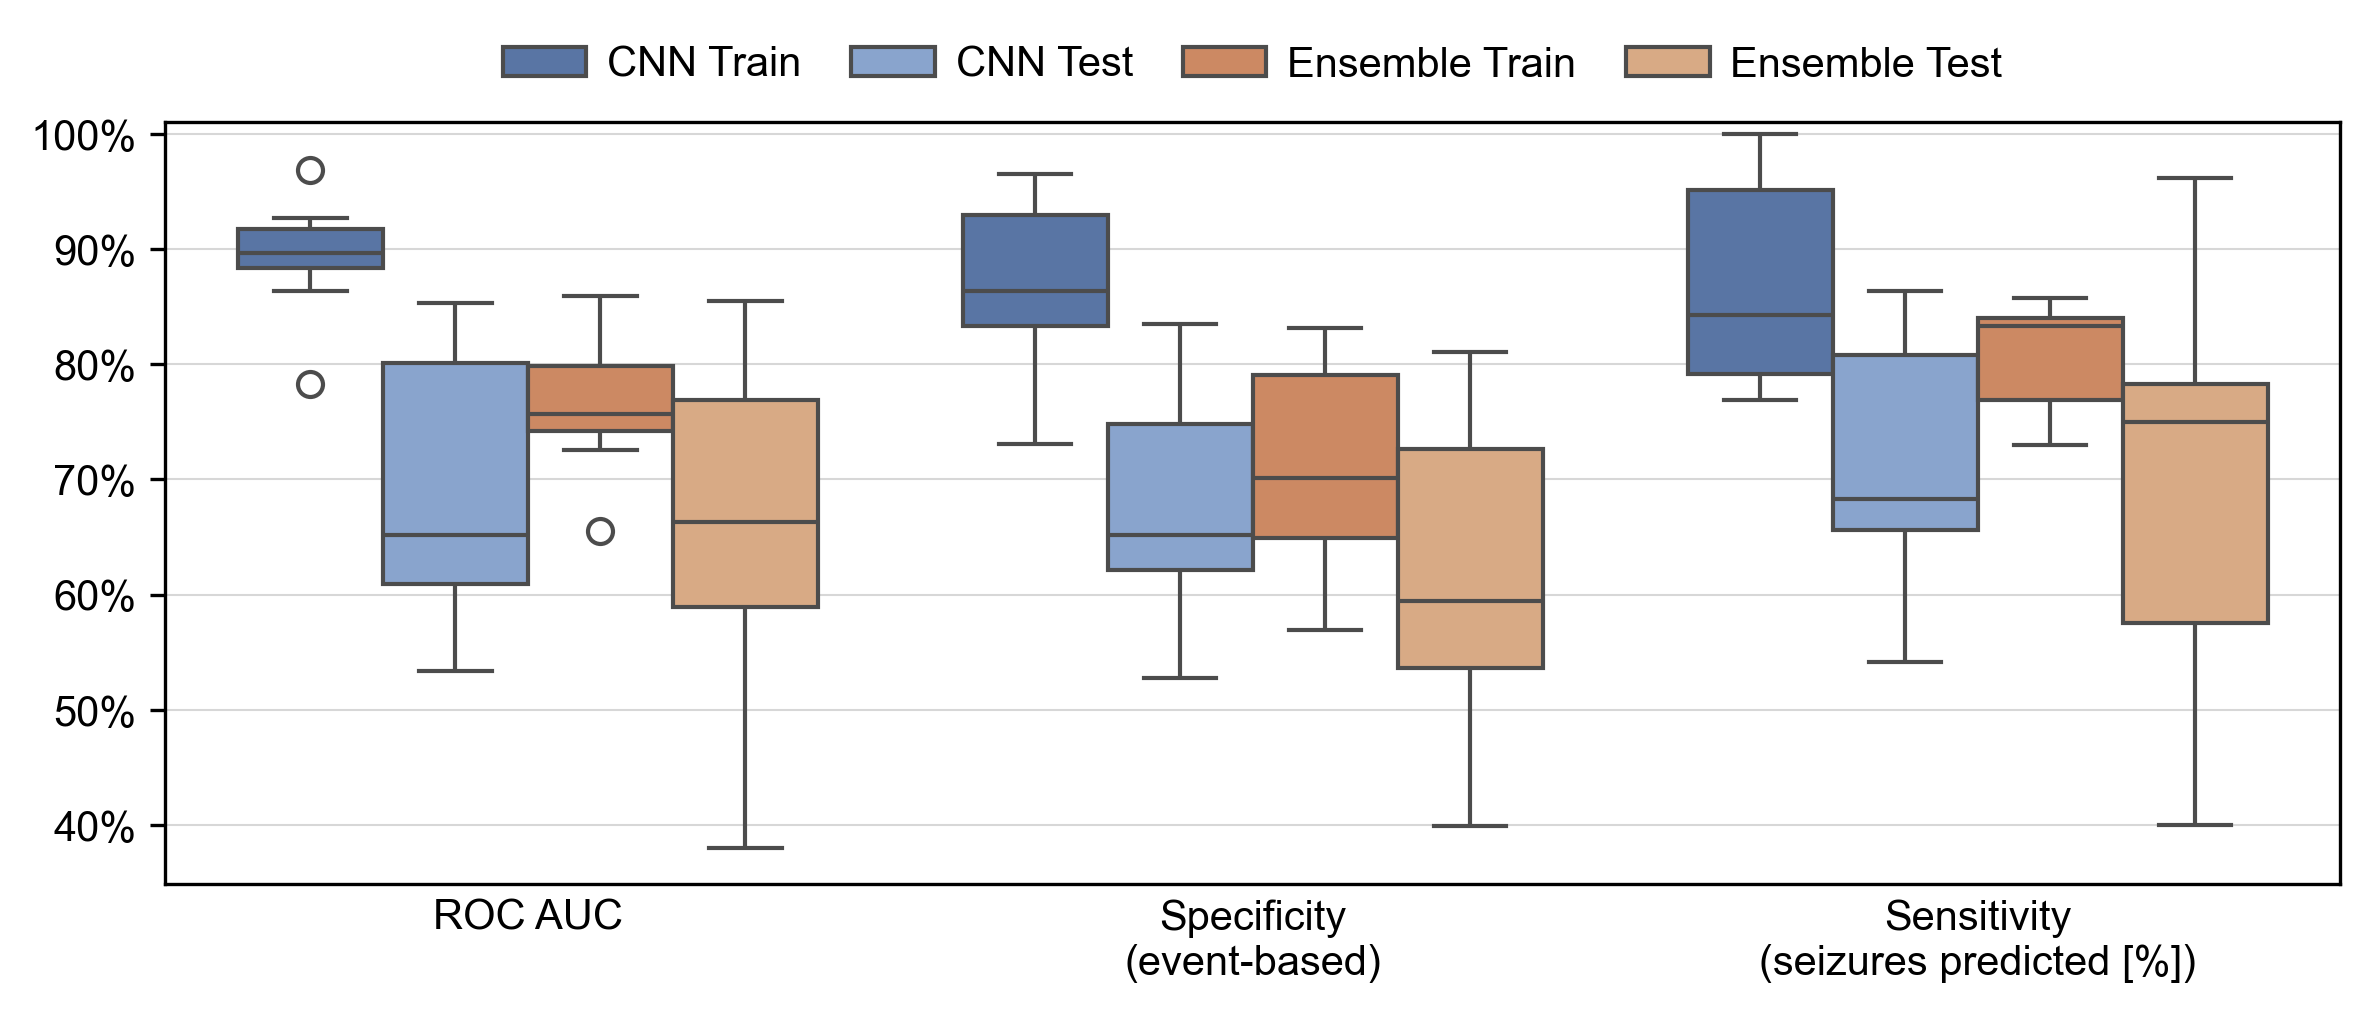

In [47]:
mpl.rcParams.update({"font.family": "arial"})

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=300)

# ---- Primary Plotting
palette = {
    "CNN Train": "#4C72B0",
    "CNN Test": "#7EA1D8",
    "Ensemble Train": "#DD8452",
    "Ensemble Test": "#E6A977",
}
sns.boxplot(data=f, x="metric", y="value", hue='Model & Partition', palette=palette, ax=ax)

# ---- Plot Formatting
# Y axis as percentages: 0%, 10%, ..., 100%
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.set_ylabel(None)
ax.set_ylim(None, 101)

# X axis
ax.set_xlabel(None)
ax.tick_params(axis='x', length=0)

ax.grid(axis='y', alpha=0.5)

ax.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    frameon=False,
    columnspacing=1.2,  # space between legend columns
    handletextpad=0.5,  # space between color box and text
    # borderpad=0.2,       # padding inside legend frame
)

fig.tight_layout()
plt.show(fig)